# Ligue 1 2025–2026 — Match Outcome Prediction

**Task:** Predict the result of each match in the 2025–2026 Ligue 1 season.
- `1` → home win
- `0` → draw
- `-1` → away win

This is a 3-class classification problem. Football outcome prediction is genuinely hard — even sophisticated commercial models rarely exceed ~55–58% accuracy on this type of task. The goal here is to beat a naive baseline by building meaningful features from historical data.

One important constraint worth mentioning upfront: for the 2025 matches, **no lineups are available**. Squad composition is never announced far enough in advance. So anything lineup-dependent needs to be approximated from historical squad stats or the clubs_fr snapshot. That forces us to think in terms of club-level signals rather than individual players.

Data available:
- Full match history 2012–2024 (~4,700 Ligue 1 games)
- Player market valuations (all seasons, FR1 only)
- Per-player per-match stats (goals, assists, cards, minutes)
- Historical lineups (2013–May 2025, not for 2025-26 season)
- Game events (goals, cards, substitutions)
- Current squad snapshot (clubs_fr)

## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    import lightgbm as lgb
    TREE_BOOSTING = True
except ImportError:
    TREE_BOOSTING = False
    print("xgboost/lightgbm not available — using sklearn GBM as fallback")

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)
np.random.seed(42)

In [2]:
# Adjust DATA_PATH if the CSVs are in a subdirectory
DATA_PATH = ""

matches    = pd.read_csv(DATA_PATH + "matchs_2013_2024.csv")
matches_25 = pd.read_csv(DATA_PATH + "match_2025.csv")
clubs      = pd.read_csv(DATA_PATH + "clubs_fr.csv")
valuations = pd.read_csv(DATA_PATH + "player_valuation_before_season.csv")
appearances= pd.read_csv(DATA_PATH + "player_appearance.csv")
lineups    = pd.read_csv(DATA_PATH + "game_lineups.csv", low_memory=False)
events     = pd.read_csv(DATA_PATH + "game_events_before2025.csv", low_memory=False)
sample     = pd.read_csv(DATA_PATH + "sample_results.csv")

print(f"Historical matches : {matches.shape}")
print(f"Matches to predict : {matches_25.shape}")
print(f"Clubs              : {clubs.shape}")
print(f"Player valuations  : {valuations.shape}")
print(f"Player appearances : {appearances.shape}")
print(f"Lineups            : {lineups.shape}")
print(f"Events             : {events.shape}")

Historical matches : (4691, 23)
Matches to predict : (233, 12)
Clubs              : (36, 13)
Player valuations  : (32856, 6)
Player appearances : (128240, 13)
Lineups            : (161049, 11)
Events             : (61944, 12)


## 2. Dataset inspection

Quick look at each table before touching anything.

In [3]:
matches.head(3)

,Unnamed: 0,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,away_club_manager_name,stadium,attendance,referee,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type,results
0,523,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,9.0,Landry Chauvin,Daniel Sanchez,Stade Francis-Le Blé,10627.0,Sébastien Moreira,NaN,NaN,Stade brestois 29,Valenciennes FC,2:1,domestic_league,1
1,524,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,10.0,Alex Dupont,Landry Chauvin,Stade François-Coty,6029.0,Olivier Thual,NaN,NaN,AC Ajaccio,Stade brestois 29,1:0,domestic_league,1
2,525,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,19.0,Hubert Fournier,Jean Fernandez,Stade Auguste-Delaune,13413.0,Jean-Charles Cailleux,NaN,NaN,Stade Reims,AS Nancy-Lorraine,2:0,domestic_league,1


In [4]:
print("Missing values in matches:")
print(matches.isnull().sum()[matches.isnull().sum() > 0])

Missing values in matches:
attendance             340
home_club_formation    396
away_club_formation    396
dtype: int64


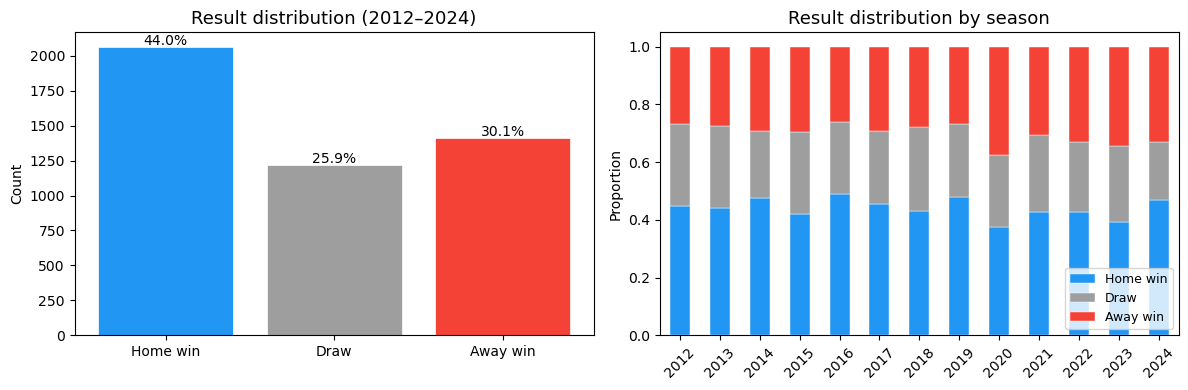


Home win rate: 0.440
Draw rate:     0.259
Away win rate: 0.301


In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

result_map = {1: 'Home win', 0: 'Draw', -1: 'Away win'}
counts = matches['results'].value_counts().reindex([1, 0, -1])
axes[0].bar([result_map[k] for k in counts.index], counts.values,
            color=['#2196F3', '#9E9E9E', '#F44336'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Result distribution (2012–2024)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, f'{v/len(matches)*100:.1f}%', ha='center', fontsize=10)

# By season
season_results = matches.groupby(['season', 'results']).size().unstack(fill_value=0)
season_results_pct = season_results.div(season_results.sum(axis=1), axis=0)
season_results_pct[[1, 0, -1]].plot(kind='bar', stacked=True, ax=axes[1],
    color=['#2196F3', '#9E9E9E', '#F44336'], edgecolor='white', linewidth=0.3)
axes[1].set_title('Result distribution by season', fontsize=13)
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('')
axes[1].legend(['Home win', 'Draw', 'Away win'], loc='lower right', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_result_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nHome win rate: {(matches.results == 1).mean():.3f}")
print(f"Draw rate:     {(matches.results == 0).mean():.3f}")
print(f"Away win rate: {(matches.results == -1).mean():.3f}")

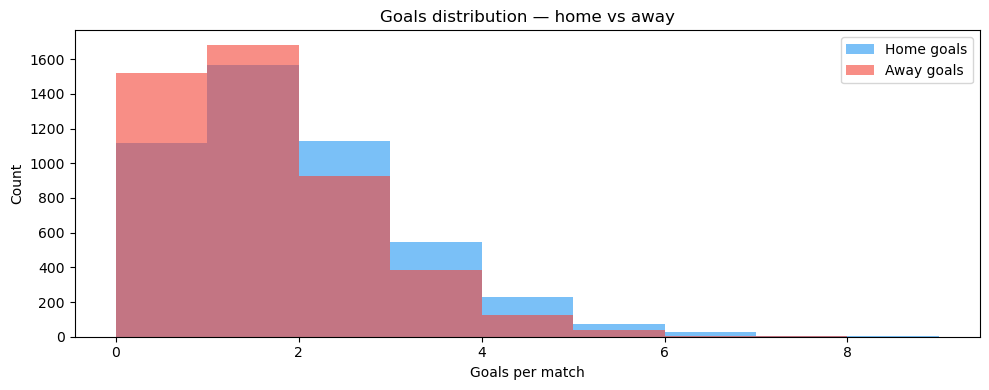

Home avg goals: 1.482
Away avg goals: 1.166
Home advantage in goals: +0.316 per game


In [6]:
# Goals distribution
fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, 10)
ax.hist(matches['home_club_goals'], bins=bins, alpha=0.6, label='Home goals', color='#2196F3')
ax.hist(matches['away_club_goals'], bins=bins, alpha=0.6, label='Away goals', color='#F44336')
ax.set_xlabel('Goals per match')
ax.set_ylabel('Count')
ax.set_title('Goals distribution — home vs away')
ax.legend()
plt.tight_layout()
plt.savefig('fig_goals_dist.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Home avg goals: {matches['home_club_goals'].mean():.3f}")
print(f"Away avg goals: {matches['away_club_goals'].mean():.3f}")
print(f"Home advantage in goals: +{matches['home_club_goals'].mean() - matches['away_club_goals'].mean():.3f} per game")

In [7]:
# Check the 'aggregate' column — this is post-match info (leakage), drop it
# Also drop the unnamed index and obvious post-match features
print(matches[['aggregate', 'home_club_goals', 'away_club_goals']].head(5))
print("\n'aggregate' contains the scoreline — pure leakage. Dropping it.")
print("'home/away_club_goals' also post-match — can only use as feature if lagged (rolling history).")

  aggregate  home_club_goals  away_club_goals
0       2:1                2                1
1       1:0                1                0
2       2:0                2                0
3       1:1                1                1
4       1:1                1                1

'aggregate' contains the scoreline — pure leakage. Dropping it.
'home/away_club_goals' also post-match — can only use as feature if lagged (rolling history).


In [8]:
# Event types available
print("Game event types:")
print(events['type'].value_counts())
print()
print("Lineup types:")
print(lineups['type'].value_counts())

Game event types:
type
Substitutions    31456
Cards            18063
Goals            12425
Name: count, dtype: int64

Lineup types:
type
starting_lineup    94490
substitutes        66559
Name: count, dtype: int64


In [9]:
# Valuation coverage — how many clubs, date range
print(f"Valuation rows: {len(valuations)}")
print(f"Date range: {valuations['date'].min()} → {valuations['date'].max()}")
print(f"Unique players: {valuations['player_id'].nunique()}")
print(f"Unique clubs: {valuations['current_club_id'].nunique()}")
print()
print("Clubs_fr snapshot (36 clubs, current season):")
clubs.head(3)

Valuation rows: 32856
Date range: 2004-10-04 → 2025-06-03
Unique players: 2701
Unique clubs: 36

Clubs_fr snapshot (36 clubs, current season):


,club_id,club_code,name,domestic_competition_id,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name
0,10004,paris-fc,Paris Football Club,FR1,31,28.5,17,54.8,9,Stade Jean Bouin,19904,€-72.30m,NaN
1,1041,olympique-lyon,Olympique Lyonnais,FR1,28,25.5,23,82.1,11,Groupama Stadium,59186,+€62.11m,NaN
2,1082,losc-lille,Lille Olympique Sporting Club,FR1,27,26.5,18,66.7,11,Decathlon Arena-Stade Pierre-Mauroy,50186,+€61.60m,NaN


## 3. Cleaning and preprocessing

In [10]:
# Parse dates
matches['date'] = pd.to_datetime(matches['date'])
matches_25['date'] = pd.to_datetime(matches_25['date'])
valuations['date'] = pd.to_datetime(valuations['date'])
appearances['date'] = pd.to_datetime(appearances['date'])
lineups['date'] = pd.to_datetime(lineups['date'])
events['date'] = pd.to_datetime(events['date'])

# Drop leakage and redundant columns
leakage_cols = ['aggregate', 'home_club_goals', 'away_club_goals', 'Unnamed: 0']
matches.drop(columns=[c for c in leakage_cols if c in matches.columns], inplace=True)

# Sort by date — important for rolling features
matches = matches.sort_values('date').reset_index(drop=True)

# Parse net_transfer_record from clubs
def parse_transfer(s):
    if pd.isna(s):
        return 0.0
    s = str(s).replace('€', '').replace('m', '').replace('+', '').replace(' ', '')
    try:
        return float(s)
    except:
        return 0.0

clubs['net_transfer_m'] = clubs['net_transfer_record'].apply(parse_transfer)
print("Transfer record parsed sample:")
print(clubs[['name', 'net_transfer_record', 'net_transfer_m']].head(5).to_string())

Transfer record parsed sample:
                            name net_transfer_record  net_transfer_m
0            Paris Football Club            €-72.30m          -72.30
1             Olympique Lyonnais            +€62.11m           62.11
2  Lille Olympique Sporting Club            +€61.60m           61.60
3                   ESTAC Troyes                 +-0           -0.00
4                     AC Ajaccio                 +-0           -0.00


In [11]:
# Quick sanity check: all 2025 match clubs exist in clubs_fr
clubs_in_2025 = set(matches_25['home_club_id'].unique()) | set(matches_25['away_club_id'].unique())
clubs_in_fr   = set(clubs['club_id'].unique())
missing_from_clubs_fr = clubs_in_2025 - clubs_in_fr
print(f"Clubs in match_2025 not in clubs_fr: {missing_from_clubs_fr}")
# If any are missing they won't get club features — we'll handle with fillna later

Clubs in match_2025 not in clubs_fr: set()


## 4. Exploratory data analysis

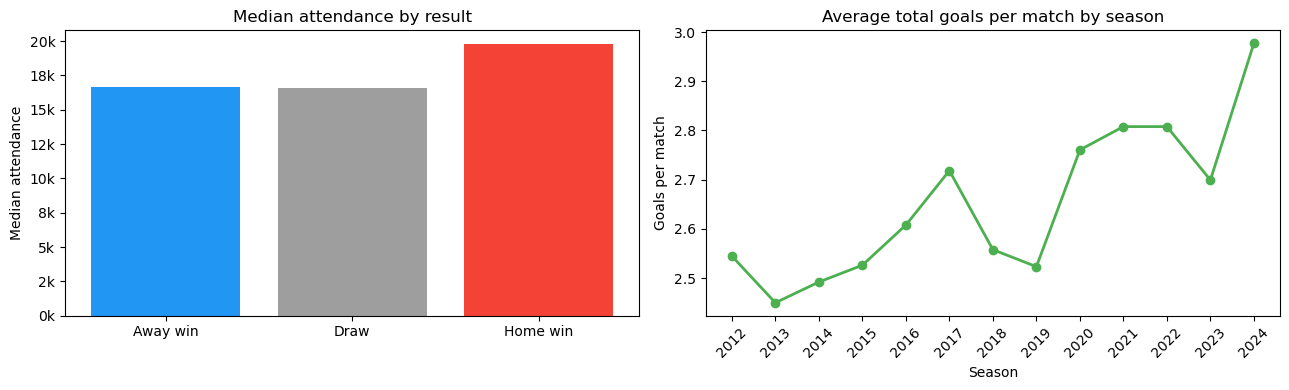

In [12]:
# Attendance vs result
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Attendance by result
att_by_result = matches.groupby('results')['attendance'].median()
axes[0].bar([result_map[k] for k in att_by_result.index], att_by_result.values,
            color=['#2196F3', '#9E9E9E', '#F44336'])
axes[0].set_title('Median attendance by result')
axes[0].set_ylabel('Median attendance')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Average goals per season
goals_season = matches.groupby('season').apply(
    lambda d: pd.Series({'home': d.assign(hg=d['home_club_goals'] if 'home_club_goals' in d.columns else np.nan)}),
    include_groups=False
)
# Recompute with original (before drop, we should use the data we loaded carefully)
# Let's reload a small version just for this plot
_m = pd.read_csv(DATA_PATH + "matchs_2013_2024.csv")
_m['date'] = pd.to_datetime(_m['date'])
goals_per_match = _m.groupby('season').apply(
    lambda d: (d['home_club_goals'] + d['away_club_goals']).mean(), include_groups=False
)
axes[1].plot(goals_per_match.index, goals_per_match.values, marker='o', color='#4CAF50', linewidth=2)
axes[1].set_title('Average total goals per match by season')
axes[1].set_ylabel('Goals per match')
axes[1].set_xlabel('Season')
axes[1].set_xticks(goals_per_match.index)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_eda_attendance_goals.png', dpi=120, bbox_inches='tight')
plt.show()

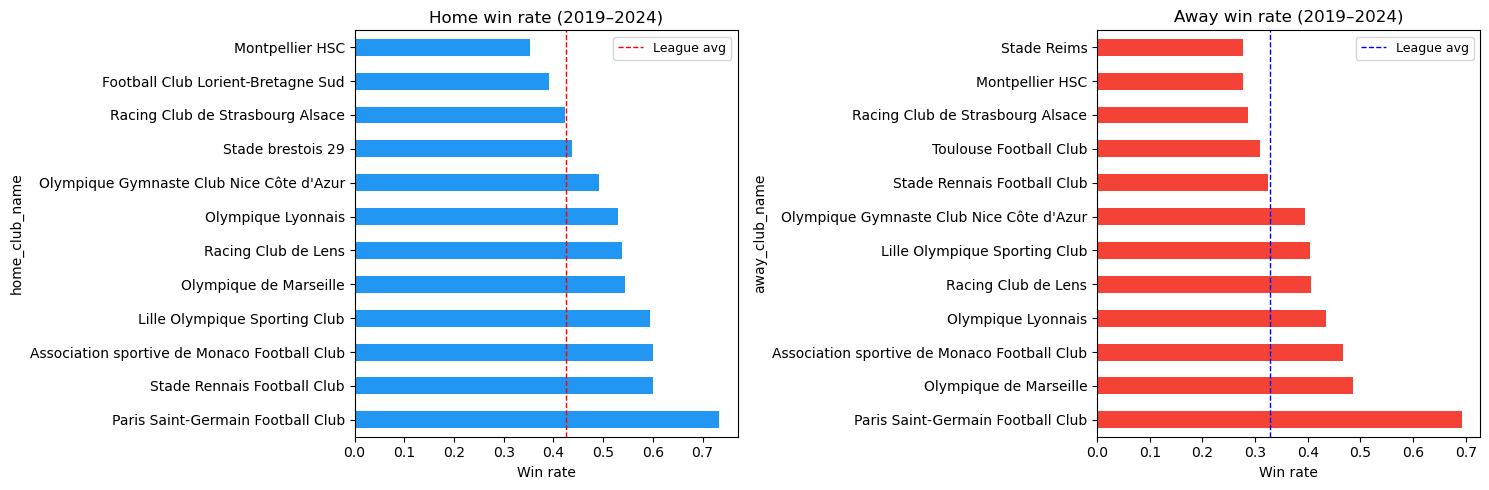

In [13]:
# Which clubs win the most at home vs away?
_m = pd.read_csv(DATA_PATH + "matchs_2013_2024.csv")
_m['date'] = pd.to_datetime(_m['date'])

# Home win rate per club (last 5 seasons for recency)
recent = _m[_m['season'] >= 2019]
home_wr = recent.groupby('home_club_name').apply(
    lambda d: (d['results'] == 1).mean(), include_groups=False
).sort_values(ascending=False).head(12)

away_wr = recent.groupby('away_club_name').apply(
    lambda d: (d['results'] == -1).mean(), include_groups=False
).sort_values(ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
home_wr.plot(kind='barh', ax=axes[0], color='#2196F3')
axes[0].set_title('Home win rate (2019–2024)', fontsize=12)
axes[0].set_xlabel('Win rate')
axes[0].axvline(recent['results'].eq(1).mean(), color='red', linestyle='--', linewidth=1, label='League avg')
axes[0].legend(fontsize=9)

away_wr.plot(kind='barh', ax=axes[1], color='#F44336')
axes[1].set_title('Away win rate (2019–2024)', fontsize=12)
axes[1].set_xlabel('Win rate')
axes[1].axvline(recent['results'].eq(-1).mean(), color='blue', linestyle='--', linewidth=1, label='League avg')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_club_win_rates.png', dpi=120, bbox_inches='tight')
plt.show()

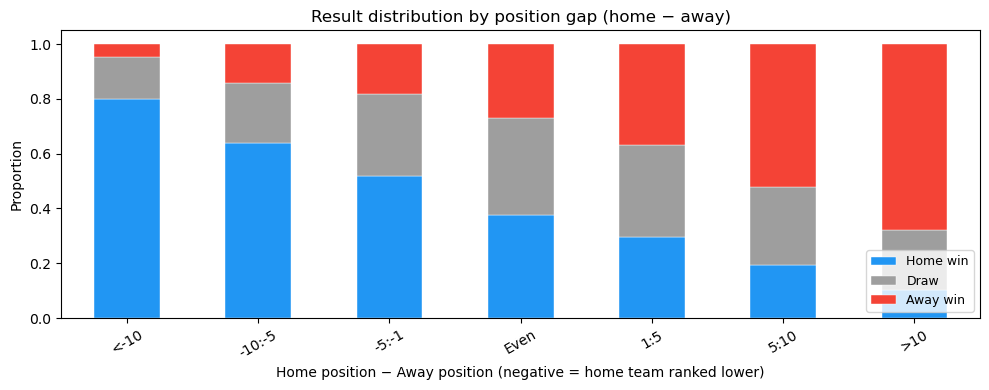

As expected: when home team is ranked much higher (positive diff), home win rate drops.
The position gap is a strong signal but available at prediction time (from previous season rank).


In [14]:
# Result by league position gap
_m['position_diff'] = _m['home_club_position'] - _m['away_club_position']
_m['pos_diff_bin'] = pd.cut(_m['position_diff'].dropna(),
                             bins=[-20, -10, -5, -1, 1, 5, 10, 20],
                             labels=['<-10', '-10:-5', '-5:-1', 'Even', '1:5', '5:10', '>10'])

pos_result = _m.groupby('pos_diff_bin', observed=True)['results'].value_counts(normalize=True).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
pos_result[[1, 0, -1]].rename(columns={1: 'Home win', 0: 'Draw', -1: 'Away win'}).plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2196F3', '#9E9E9E', '#F44336'], edgecolor='white', linewidth=0.3)
ax.set_title('Result distribution by position gap (home − away)', fontsize=12)
ax.set_xlabel('Home position − Away position (negative = home team ranked lower)')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_position_gap_result.png', dpi=120, bbox_inches='tight')
plt.show()
print("As expected: when home team is ranked much higher (positive diff), home win rate drops.")
print("The position gap is a strong signal but available at prediction time (from previous season rank).")

## 5. Temporal analysis — Elo ratings

Before jumping into feature engineering, let's build an Elo rating system. This ends up being one of the most useful single features.

The update rule is standard: after a match, winner gains K × (1 − expected) points, loser loses the same. Expected outcome is based on the rating difference via the logistic function.

One subtlety: we need to be careful that the Elo we assign to a match is the Elo *before* that match. We update it after.

In [15]:
def compute_elo(matches_df, k=30, initial=1500):
    """
    Compute Elo ratings for all clubs over the match history.
    Returns the input dataframe with 'home_elo_before' and 'away_elo_before' columns.
    """
    elo = {}
    home_elo_before = []
    away_elo_before = []

    for _, row in matches_df.iterrows():
        h = row['home_club_id']
        a = row['away_club_id']
        r = row['results']  # 1, 0, -1

        elo.setdefault(h, initial)
        elo.setdefault(a, initial)

        # Expected outcomes
        exp_h = 1 / (1 + 10 ** ((elo[a] - elo[h]) / 400))
        exp_a = 1 - exp_h

        home_elo_before.append(elo[h])
        away_elo_before.append(elo[a])

        # Actual scores (football version: win=1, draw=0.5, loss=0)
        actual_h = 1 if r == 1 else (0.5 if r == 0 else 0)
        actual_a = 1 - actual_h

        elo[h] += k * (actual_h - exp_h)
        elo[a] += k * (actual_a - exp_a)

    result_df = matches_df.copy()
    result_df['home_elo_before'] = home_elo_before
    result_df['away_elo_before'] = away_elo_before
    result_df['elo_diff'] = result_df['home_elo_before'] - result_df['away_elo_before']
    return result_df, elo

matches, final_elo = compute_elo(matches)
print("Elo computed.")
print(f"Top 5 Elo at end of 2024:")
top_elo = sorted(final_elo.items(), key=lambda x: x[1], reverse=True)[:5]
# Map ids to names
id_to_name = dict(zip(pd.concat([matches[['home_club_id','home_club_name']].rename(columns={'home_club_id':'id','home_club_name':'name'}),
                                   matches[['away_club_id','away_club_name']].rename(columns={'away_club_id':'id','away_club_name':'name'})]).drop_duplicates()['id'],
                      pd.concat([matches[['home_club_id','home_club_name']].rename(columns={'home_club_id':'id','home_club_name':'name'}),
                                   matches[['away_club_id','away_club_name']].rename(columns={'away_club_id':'id','away_club_name':'name'})]).drop_duplicates()['name']))
for cid, e in top_elo:
    print(f"  {id_to_name.get(cid, cid)}: {e:.0f}")

Elo computed.
Top 5 Elo at end of 2024:
  Paris Saint-Germain Football Club: 1826
  Association sportive de Monaco Football Club: 1669
  Lille Olympique Sporting Club: 1661
  Olympique Gymnaste Club Nice Côte d'Azur: 1659
  Olympique de Marseille: 1658


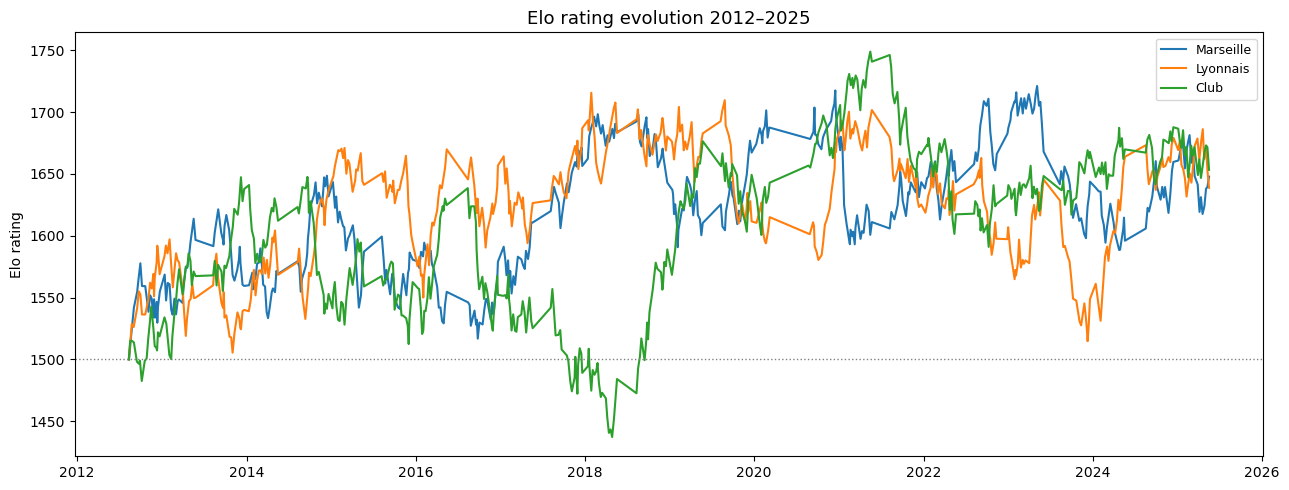

In [16]:
# Elo evolution for a few clubs
clubs_to_plot = ['Paris Saint-Germain', 'Olympique de Marseille', 
                 'Olympique Lyonnais', 'AS Monaco', 'Lille Olympique Sporting Club']

fig, ax = plt.subplots(figsize=(13, 5))

for club_name in clubs_to_plot:
    club_id = matches[matches['home_club_name'] == club_name]['home_club_id'].iloc[0] if len(matches[matches['home_club_name'] == club_name]) > 0 else None
    if club_id is None:
        continue
    # Home games Elo progression (using pre-match Elo by date)
    sub = matches[matches['home_club_id'] == club_id][['date', 'home_elo_before']].copy()
    sub2 = matches[matches['away_club_id'] == club_id][['date', 'away_elo_before']].rename(columns={'away_elo_before': 'home_elo_before'})
    elo_series = pd.concat([sub, sub2]).sort_values('date')
    ax.plot(elo_series['date'], elo_series['home_elo_before'], label=club_name.split()[-1], linewidth=1.5)

ax.set_title('Elo rating evolution 2012–2025', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Elo rating')
ax.axhline(1500, color='gray', linestyle=':', linewidth=1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_elo_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# Predictive power of Elo diff
from sklearn.metrics import accuracy_score

# Naive Elo classifier: predict home win if elo_diff > 50, draw if |elo_diff| < 50, else away
def elo_predict(diff, thresh=50):
    if diff > thresh: return 1
    elif diff < -thresh: return -1
    else: return 0

elo_preds = matches['elo_diff'].apply(elo_predict)
print(f"Elo classifier accuracy: {accuracy_score(matches['results'], elo_preds):.3f}")
print(f"Always home win baseline: {(matches['results'] == 1).mean():.3f}")

# Check correlation between elo_diff and result
corr = matches['elo_diff'].corr(matches['results'])
print(f"Elo diff / result correlation: {corr:.3f}")

Elo classifier accuracy: 0.454
Always home win baseline: 0.440
Elo diff / result correlation: 0.337


## 6. Feature engineering

This is the main section. The strategy:
1. Build rolling form features (per club, avoiding leakage with shift(1))
2. Build head-to-head features
3. Pull in club-level signals (Elo diff, squad value, clubs_fr)
4. Aggregate player valuations per club

All features need to be computable for `match_2025.csv` as well — so anything that requires lineup data gets approximated.

In [18]:
# ── 6.1 Rolling form features ──
# For each match, compute rolling stats for both home and away club
# over their last N matches (strictly before this match)

def build_rolling_features(df, n=5):
    """Build rolling form features per club."""
    # We need the full match history sorted by date
    # For each club, we look at their last N games regardless of H/A
    
    _m_full = pd.read_csv(DATA_PATH + "matchs_2013_2024.csv")
    _m_full['date'] = pd.to_datetime(_m_full['date'])
    _m_full = _m_full.sort_values('date').reset_index(drop=True)

    # Build a per-club match list with result from their perspective
    home_side = _m_full[['game_id','date','home_club_id','away_club_id',
                           'home_club_goals','away_club_goals','results']].copy()
    home_side['club_id'] = home_side['home_club_id']
    home_side['opp_id']  = home_side['away_club_id']
    home_side['gf']      = home_side['home_club_goals']
    home_side['ga']      = home_side['away_club_goals']
    home_side['result_club'] = home_side['results']           # 1=win, 0=draw, -1=loss
    home_side['is_home'] = 1

    away_side = _m_full[['game_id','date','home_club_id','away_club_id',
                           'home_club_goals','away_club_goals','results']].copy()
    away_side['club_id'] = away_side['away_club_id']
    away_side['opp_id']  = away_side['home_club_id']
    away_side['gf']      = away_side['away_club_goals']
    away_side['ga']      = away_side['home_club_goals']
    away_side['result_club'] = -away_side['results']          # flip sign: 1=win from away perspective
    away_side['is_home'] = 0

    club_games = pd.concat([
        home_side[['game_id','date','club_id','opp_id','gf','ga','result_club','is_home']],
        away_side[['game_id','date','club_id','opp_id','gf','ga','result_club','is_home']]
    ]).sort_values(['club_id','date']).reset_index(drop=True)

    # Points: win=3, draw=1, loss=0
    club_games['points'] = club_games['result_club'].map({1:3, 0:1, -1:0})
    club_games['win']    = (club_games['result_club'] == 1).astype(int)
    club_games['draw']   = (club_games['result_club'] == 0).astype(int)

    # Shift before rolling to avoid using the current match
    club_games = club_games.sort_values(['club_id','date']).reset_index(drop=True)

    roll_cols = {}
    for col, label in [('points', 'pts'), ('gf', 'gf'), ('ga', 'ga'), ('win', 'win')]:
        r = club_games.groupby('club_id')[col].transform(
            lambda x: x.shift(1).rolling(n, min_periods=1).mean()
        )
        roll_cols[f'roll_{label}_{n}'] = r

    for k, v in roll_cols.items():
        club_games[k] = v

    return club_games

print("Building rolling features...")
club_games_df = build_rolling_features(matches, n=5)
print(f"Club-games table: {club_games_df.shape}")
print(club_games_df[['game_id','club_id','date','roll_pts_5','roll_gf_5','roll_ga_5']].head(8).to_string())

Building rolling features...
Club-games table: (9382, 15)
   game_id  club_id       date  roll_pts_5  roll_gf_5  roll_ga_5
0  2229834       40 2012-08-11         NaN        NaN        NaN
1  2229845       40 2012-08-19    3.000000   3.000000   2.000000
2  2229863       40 2012-08-26    3.000000   2.000000   1.000000
3  2223888       40 2012-09-02    2.333333   1.333333   0.666667
4  2223852       40 2012-09-15    2.000000   1.250000   0.750000
5  2223851       40 2012-09-23    1.800000   1.000000   0.600000
6  2223867       40 2012-09-30    1.400000   0.800000   0.600000
7  2223875       40 2012-10-07    1.400000   1.000000   0.600000


In [19]:
# Merge rolling features back to matches
def merge_rolling_to_matches(df, club_games_df, n=5):
    roll_cols = [c for c in club_games_df.columns if c.startswith('roll_')]

    home_roll = club_games_df[['game_id','club_id'] + roll_cols].copy()
    home_roll.columns = ['game_id','home_club_id'] + [f'home_{c}' for c in roll_cols]

    away_roll = club_games_df[['game_id','club_id'] + roll_cols].copy()
    away_roll.columns = ['game_id','away_club_id'] + [f'away_{c}' for c in roll_cols]

    df = df.merge(home_roll, on=['game_id','home_club_id'], how='left')
    df = df.merge(away_roll, on=['game_id','away_club_id'], how='left')
    return df

matches = merge_rolling_to_matches(matches, club_games_df)
print("Rolling features merged.")
roll_cols_check = [c for c in matches.columns if c.startswith('home_roll_')]
print("Home rolling columns:", roll_cols_check)

Rolling features merged.
Home rolling columns: ['home_roll_pts_5', 'home_roll_gf_5', 'home_roll_ga_5', 'home_roll_win_5']


In [20]:
# ── 6.2 Days since last match (fatigue proxy) ──
def add_rest_days(df, club_games_df):
    last_game = club_games_df.groupby(['club_id', 'game_id'])['date'].first().reset_index()
    last_game = last_game.sort_values(['club_id','date'])
    last_game['prev_date'] = last_game.groupby('club_id')['date'].shift(1)
    last_game['days_rest'] = (last_game['date'] - last_game['prev_date']).dt.days

    home_rest = last_game[['game_id','club_id','days_rest']].copy()
    home_rest.columns = ['game_id','home_club_id','home_days_rest']
    away_rest = last_game[['game_id','club_id','days_rest']].copy()
    away_rest.columns = ['game_id','away_club_id','away_days_rest']

    df = df.merge(home_rest, on=['game_id','home_club_id'], how='left')
    df = df.merge(away_rest, on=['game_id','away_club_id'], how='left')
    return df

matches = add_rest_days(matches, club_games_df)
print(f"Rest days — home median: {matches['home_days_rest'].median():.0f}, away median: {matches['away_days_rest'].median():.0f}")

Rest days — home median: 7, away median: 7


In [21]:
# ── 6.3 Squad market value aggregation ──
# For each match, compute the total squad value of each club as of the match date
# using the most recent valuation before that date per player

print("Computing squad values... (this takes a moment)")

# Only keep most recent valuation per player per date range
valuations_sorted = valuations.sort_values(['player_id','date'])

def club_squad_value_asof(match_df, valuations_df):
    """
    For each match, compute total squad market value for home and away club.
    Uses the most recent valuation before match date for each player.
    """
    # Create a snapshot: for each (club, year-month), what was the total squad value?
    # Approximation: group valuations by club and take the latest per player per season
    val = valuations_df.copy()
    val['season'] = val['date'].dt.year  # approximate season by year
    
    # For each player, keep only the latest valuation before or at each match season
    # Simplified: latest valuation per player per club
    latest_val = val.sort_values('date').groupby(['current_club_id','player_id']).last().reset_index()
    
    # Total squad value and count per club
    squad_val = latest_val.groupby('current_club_id').agg(
        squad_total_value=('market_value_in_eur', 'sum'),
        squad_avg_value=('market_value_in_eur', 'mean'),
        squad_player_count=('player_id', 'count')
    ).reset_index()
    squad_val.columns = ['club_id', 'squad_total_value', 'squad_avg_value', 'squad_player_count']
    
    return squad_val

squad_values = club_squad_value_asof(matches, valuations)
print(f"Squad values computed for {len(squad_values)} clubs")

# Merge to matches
home_sv = squad_values.rename(columns={'club_id':'home_club_id', 
    'squad_total_value':'home_squad_value', 'squad_avg_value':'home_squad_avg_value',
    'squad_player_count':'home_squad_count'})
away_sv = squad_values.rename(columns={'club_id':'away_club_id',
    'squad_total_value':'away_squad_value', 'squad_avg_value':'away_squad_avg_value',
    'squad_player_count':'away_squad_count'})

matches = matches.merge(home_sv[['home_club_id','home_squad_value','home_squad_avg_value']], on='home_club_id', how='left')
matches = matches.merge(away_sv[['away_club_id','away_squad_value','away_squad_avg_value']], on='away_club_id', how='left')
matches['squad_value_ratio'] = matches['home_squad_value'] / (matches['away_squad_value'] + 1e-6)
print("Squad value ratio computed.")

Computing squad values... (this takes a moment)
Squad values computed for 36 clubs
Squad value ratio computed.


In [22]:
# ── 6.4 Club-level features from clubs_fr ──
clubs_features = clubs[['club_id', 'squad_size', 'average_age',
                          'foreigners_percentage', 'national_team_players',
                          'stadium_seats', 'net_transfer_m']].copy()

home_cf = clubs_features.rename(columns={
    'club_id': 'home_club_id',
    'squad_size': 'home_squad_size',
    'average_age': 'home_average_age',
    'foreigners_percentage': 'home_foreigners_percentage',
    'national_team_players': 'home_national_team_players',
    'stadium_seats': 'home_stadium_seats',
    'net_transfer_m': 'home_net_transfer_m'
})

away_cf = clubs_features.rename(columns={
    'club_id': 'away_club_id',
    'squad_size': 'away_squad_size',
    'average_age': 'away_average_age',
    'foreigners_percentage': 'away_foreigners_percentage',
    'national_team_players': 'away_national_team_players',
    'stadium_seats': 'away_stadium_seats',
    'net_transfer_m': 'away_net_transfer_m'
})

matches_25 = matches_25.merge(home_cf, on='home_club_id', how='left')
matches_25 = matches_25.merge(away_cf, on='away_club_id', how='left')
print("clubs_fr features merged into match_2025.")
print(matches_25[[c for c in matches_25.columns if 'national_team' in c or 'net_transfer' in c]].head(3).to_string())

clubs_fr features merged into match_2025.
   home_national_team_players  home_net_transfer_m  away_national_team_players  away_net_transfer_m
0                           9                50.15                          14                20.55
1                          10                45.60                          11                62.11
2                          13                72.82                           7                31.85


In [23]:
# ── 6.5 Head-to-head features ──
# For each match, compute home win rate in historical meetings of the same pair

_m_full = pd.read_csv(DATA_PATH + "matchs_2013_2024.csv")
_m_full['date'] = pd.to_datetime(_m_full['date'])
_m_full = _m_full.sort_values('date').reset_index(drop=True)

h2h_records = []
for idx, row in matches.iterrows():
    h, a = row['home_club_id'], row['away_club_id']
    d = row['date']
    # Only matches before this one between these two teams
    prev = _m_full[
        (_m_full['date'] < d) &
        ((_m_full['home_club_id'] == h) & (_m_full['away_club_id'] == a))
    ]
    if len(prev) > 0:
        h2h_home_wr = (prev['results'] == 1).mean()
        h2h_n = len(prev)
    else:
        h2h_home_wr = np.nan  # no prior meetings
        h2h_n = 0
    h2h_records.append({'game_id': row['game_id'], 'h2h_home_wr': h2h_home_wr, 'h2h_n': h2h_n})

h2h_df = pd.DataFrame(h2h_records)
matches = matches.merge(h2h_df, on='game_id', how='left')
print("H2H features merged.")
print(f"Matches with H2H data: {matches['h2h_n'].gt(0).sum()} / {len(matches)}")

H2H features merged.
Matches with H2H data: 3677 / 4691


In [24]:
# ── 6.6 Temporal / contextual features ──
matches['month'] = matches['date'].dt.month
matches['day_of_week'] = matches['date'].dt.dayofweek  # 0=Monday
matches['is_weekend'] = matches['day_of_week'].isin([5, 6]).astype(int)

# Season stage: matchday number within the season
matches['matchday_in_season'] = matches.groupby('season')['date'].transform(
    lambda x: pd.Series(range(len(x)), index=x.sort_values().index).reindex(x.index) + 1
)
matches['season_progress'] = matches['matchday_in_season'] / matches.groupby('season')['date'].transform('count')

print("Temporal features added.")
matches[['date','season','matchday_in_season','season_progress']].head(5)

Temporal features added.


,date,season,matchday_in_season,season_progress
0,2012-08-10,2012,1,0.002632
1,2012-08-11,2012,2,0.005263
2,2012-08-11,2012,3,0.007895
3,2012-08-11,2012,4,0.010526
4,2012-08-11,2012,5,0.013158


In [25]:
def add_streaks(df, club_games_df):
    cg = club_games_df.sort_values(['club_id','date']).copy()
    
    def compute_streak(arr, condition_val):
        streaks = []
        for i in range(len(arr)):
            prev = arr[:i][::-1]  # already a numpy array, no .values needed
            count = 0
            for v in prev:
                if v == condition_val:
                    count += 1
                else:
                    break
            streaks.append(count)
        return streaks

    import itertools
    win_streaks = {}
    unbeaten_streaks = {}
    
    for club_id, grp in cg.groupby('club_id'):
        results_arr = grp['result_club'].values
        game_ids = grp['game_id'].values
        ws = compute_streak(results_arr, 1)
        us = [sum(1 for _ in itertools.takewhile(lambda x: x != -1,
               results_arr[:i][::-1])) for i in range(len(results_arr))]
        for gid, w, u in zip(game_ids, ws, us):
            win_streaks[gid, club_id] = w
            unbeaten_streaks[gid, club_id] = u

    home_ws = [win_streaks.get((r['game_id'], r['home_club_id']), 0) for _, r in df.iterrows()]
    away_ws = [win_streaks.get((r['game_id'], r['away_club_id']), 0) for _, r in df.iterrows()]
    home_us = [unbeaten_streaks.get((r['game_id'], r['home_club_id']), 0) for _, r in df.iterrows()]
    away_us = [unbeaten_streaks.get((r['game_id'], r['away_club_id']), 0) for _, r in df.iterrows()]
    
    df['home_win_streak'] = home_ws
    df['away_win_streak'] = away_ws
    df['home_unbeaten_streak'] = home_us
    df['away_unbeaten_streak'] = away_us
    return df

matches = add_streaks(matches, club_games_df)
print("Streak features added.")
print(matches[['home_club_name','away_club_name','home_win_streak','away_win_streak']].tail(5).to_string())

Streak features added.
                         home_club_name                         away_club_name  home_win_streak  away_win_streak
4686                   AS Saint-Étienne                 Toulouse Football Club                1                0
4687      Lille Olympique Sporting Club                            Stade Reims                0                0
4688   Racing Club de Strasbourg Alsace                 Le Havre Athletic Club                0                0
4689            Football Club de Nantes                        Montpellier HSC                0                0
4690  Paris Saint-Germain Football Club  Association de la Jeunesse auxerroise                1                0


In [26]:
# ── 6.8 Summary of engineered features ──
feature_cols = [
    # Elo
    'elo_diff', 'home_elo_before', 'away_elo_before',
    # Rolling form
    'home_roll_pts_5', 'away_roll_pts_5',
    'home_roll_gf_5', 'away_roll_gf_5',
    'home_roll_ga_5', 'away_roll_ga_5',
    'home_roll_win_5', 'away_roll_win_5',
    # Rest
    'home_days_rest', 'away_days_rest',
    # Squad value
    'squad_value_ratio', 'home_squad_value', 'away_squad_value',
    # H2H
    'h2h_home_wr',
    # Streaks
    'home_win_streak', 'away_win_streak',
    'home_unbeaten_streak', 'away_unbeaten_streak',
    # Temporal
    'season_progress', 'month', 'is_weekend',
]

# Keep only available columns
feature_cols = [c for c in feature_cols if c in matches.columns]
print(f"Total features: {len(feature_cols)}")

# Missing value check
X_raw = matches[feature_cols]
print("\nMissing values per feature:")
print(X_raw.isnull().sum()[X_raw.isnull().sum() > 0])

Total features: 24

Missing values per feature:
home_roll_pts_5      13
away_roll_pts_5      22
home_roll_gf_5       13
away_roll_gf_5       22
home_roll_ga_5       13
away_roll_ga_5       22
home_roll_win_5      13
away_roll_win_5      22
home_days_rest       13
away_days_rest       22
h2h_home_wr        1014
dtype: int64


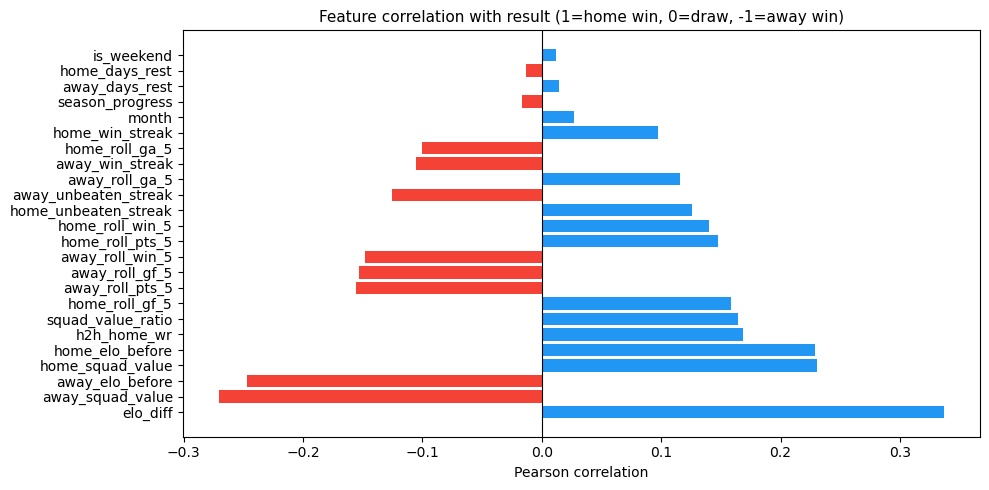

In [27]:
# Correlation of features with target
y = matches['results']
corr_with_target = X_raw.apply(lambda c: c.corr(y)).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature correlation with result (1=home win, 0=draw, -1=away win)', fontsize=11)
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.savefig('fig_feature_corr.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Baseline models

Before doing anything sophisticated, let's establish what we're trying to beat. Three baselines:
1. Always predict home win
2. Predict proportional to class frequency (random weighted)
3. Logistic regression on a minimal feature set

Also running a quick sanity check on cross-validation setup.

In [28]:
# ── Prepare training data ──
from sklearn.impute import SimpleImputer

X_all = matches[feature_cols].copy()
y_all = matches['results'].copy()

# Impute missing values (median for rolling/rest features, 0 for H2H when no prior meetings)
X_all['h2h_home_wr'] = X_all['h2h_home_wr'].fillna(0.44)  # league avg home win rate
imputer = SimpleImputer(strategy='median')
X_all_imp = pd.DataFrame(imputer.fit_transform(X_all), columns=X_all.columns)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training samples: {len(X_all_imp)}")
print(f"Class distribution: {y_all.value_counts().to_dict()}")

Training samples: 4691
Class distribution: {1: 2065, -1: 1410, 0: 1216}


In [29]:
# Baseline 1: always home win
baseline_homwin = np.ones(len(y_all), dtype=int)
print(f"Always-home-win accuracy: {accuracy_score(y_all, baseline_homwin):.4f}")
print(f"Always-home-win F1-macro: {f1_score(y_all, baseline_homwin, average='macro', zero_division=0):.4f}")
print()

# Baseline 2: majority class
from collections import Counter
majority = Counter(y_all).most_common(1)[0][0]
baseline_majority = np.full(len(y_all), majority)
print(f"Majority class accuracy: {accuracy_score(y_all, baseline_majority):.4f}")
print()

# Baseline 3: logistic regression on elo_diff only
lr_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])
lr_simple_scores = cross_val_score(lr_simple, X_all_imp[['elo_diff']], y_all, cv=cv, scoring='accuracy')
print(f"Logistic (elo only) accuracy: {lr_simple_scores.mean():.4f} ± {lr_simple_scores.std():.4f}")

Always-home-win accuracy: 0.4402
Always-home-win F1-macro: 0.2038

Majority class accuracy: 0.4402

Logistic (elo only) accuracy: 0.5042 ± 0.0136


## 8. Model comparison

Now training on the full feature set. Using StratifiedKFold to handle class imbalance properly. Tracking both accuracy and macro F1 (macro F1 penalizes ignoring the minority class).

Draws are always the hardest class — expect poor recall on class 0.

In [30]:
results_tracker = {}

# ── Random Forest ──
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10, 
                              class_weight='balanced', random_state=42, n_jobs=-1)
cv_rf = cross_validate(rf, X_all_imp, y_all, cv=cv, 
                        scoring=['accuracy', 'f1_macro'], return_train_score=True)
results_tracker['RandomForest'] = {
    'val_acc': cv_rf['test_accuracy'].mean(),
    'val_f1': cv_rf['test_f1_macro'].mean(),
    'train_acc': cv_rf['train_accuracy'].mean(),
}
print(f"Random Forest — val acc: {results_tracker['RandomForest']['val_acc']:.4f}, "
      f"val F1-macro: {results_tracker['RandomForest']['val_f1']:.4f}, "
      f"train acc: {results_tracker['RandomForest']['train_acc']:.4f}")

Random Forest — val acc: 0.4790, val F1-macro: 0.4522, train acc: 0.6385


In [31]:
# ── Gradient Boosting ──
gbc = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                   subsample=0.8, random_state=42)
cv_gbc = cross_validate(gbc, X_all_imp, y_all, cv=cv,
                         scoring=['accuracy', 'f1_macro'], return_train_score=True)
results_tracker['GradientBoosting'] = {
    'val_acc': cv_gbc['test_accuracy'].mean(),
    'val_f1': cv_gbc['test_f1_macro'].mean(),
    'train_acc': cv_gbc['train_accuracy'].mean(),
}
print(f"Gradient Boosting — val acc: {results_tracker['GradientBoosting']['val_acc']:.4f}, "
      f"val F1-macro: {results_tracker['GradientBoosting']['val_f1']:.4f}, "
      f"train acc: {results_tracker['GradientBoosting']['train_acc']:.4f}")

Gradient Boosting — val acc: 0.4926, val F1-macro: 0.4185, train acc: 0.7509


In [32]:
# ── Logistic Regression (full features) ──
lr_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42))
])
cv_lr = cross_validate(lr_full, X_all_imp, y_all, cv=cv,
                        scoring=['accuracy', 'f1_macro'], return_train_score=True)
results_tracker['LogisticRegression'] = {
    'val_acc': cv_lr['test_accuracy'].mean(),
    'val_f1': cv_lr['test_f1_macro'].mean(),
    'train_acc': cv_lr['train_accuracy'].mean(),
}
print(f"Logistic Regression — val acc: {results_tracker['LogisticRegression']['val_acc']:.4f}, "
      f"val F1-macro: {results_tracker['LogisticRegression']['val_f1']:.4f}, "
      f"train acc: {results_tracker['LogisticRegression']['train_acc']:.4f}")

Logistic Regression — val acc: 0.4750, val F1-macro: 0.4520, train acc: 0.4854


In [33]:
# ── XGBoost (if available) ──
if TREE_BOOSTING:
    # Remap labels: XGBoost needs 0-indexed classes
    label_map  = {1: 2, 0: 1, -1: 0}
    ilabel_map = {2: 1, 1: 0, 0: -1}
    y_xgb = y_all.map(label_map)
    
    xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    use_label_encoder=False, eval_metric='mlogloss',
                                    random_state=42)
    cv_xgb = cross_validate(xgb_model, X_all_imp, y_xgb, cv=cv,
                             scoring=['accuracy', 'f1_macro'], return_train_score=True)
    results_tracker['XGBoost'] = {
        'val_acc': cv_xgb['test_accuracy'].mean(),
        'val_f1': cv_xgb['test_f1_macro'].mean(),
        'train_acc': cv_xgb['train_accuracy'].mean(),
    }
    print(f"XGBoost — val acc: {results_tracker['XGBoost']['val_acc']:.4f}, "
          f"val F1-macro: {results_tracker['XGBoost']['val_f1']:.4f}")
else:
    print("XGBoost not available — skipping. Install with: pip install xgboost lightgbm")

XGBoost — val acc: 0.4877, val F1-macro: 0.4186


                    val_acc  val_f1  train_acc  overfit_gap
GradientBoosting     0.4926  0.4185     0.7509       0.2583
XGBoost              0.4877  0.4186     0.8813       0.3936
RandomForest         0.4790  0.4522     0.6385       0.1595
LogisticRegression   0.4750  0.4520     0.4854       0.0104


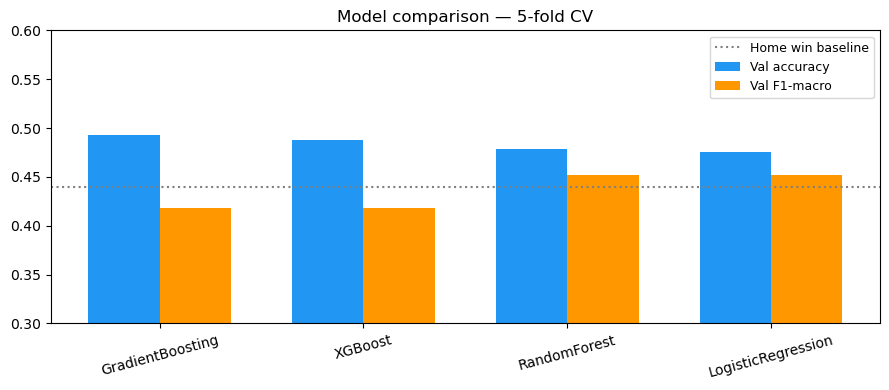

In [34]:
# ── Compare models ──
results_df = pd.DataFrame(results_tracker).T
results_df['overfit_gap'] = results_df['train_acc'] - results_df['val_acc']
results_df = results_df.sort_values('val_acc', ascending=False)
print(results_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(results_df))
ax.bar(x, results_df['val_acc'], width=0.35, label='Val accuracy', color='#2196F3')
ax.bar([i+0.35 for i in x], results_df['val_f1'], width=0.35, label='Val F1-macro', color='#FF9800')
ax.axhline(0.44, color='gray', linestyle=':', label='Home win baseline')
ax.set_xticks([i+0.175 for i in x])
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_title('Model comparison — 5-fold CV')
ax.set_ylim(0.3, 0.6)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Things that didn't work (or not as expected)

It's worth documenting experiments that failed — not to pad the notebook, but because these failures inform what matters.

In [35]:
# Experiment: does including raw attendance help?
# Intuitively: big crowds might give home advantage. Let's test.

att_feature = matches[['attendance']].copy()
att_feature['attendance'] = att_feature['attendance'].fillna(att_feature['attendance'].median())

X_with_att = pd.concat([X_all_imp, att_feature.reset_index(drop=True)], axis=1)
rf_att = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
scores_att = cross_val_score(rf_att, X_with_att, y_all, cv=cv, scoring='accuracy')
scores_base = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1),
    X_all_imp, y_all, cv=cv, scoring='accuracy'
)
print(f"RF with attendance:    {scores_att.mean():.4f} ± {scores_att.std():.4f}")
print(f"RF without attendance: {scores_base.mean():.4f} ± {scores_base.std():.4f}")
print()
print("Attendance doesn't seem to add much. Makes sense — it's correlated with club quality")
print("which is already captured by Elo and squad value.")

RF with attendance:    0.5046 ± 0.0115
RF without attendance: 0.5033 ± 0.0138

Attendance doesn't seem to add much. Makes sense — it's correlated with club quality
which is already captured by Elo and squad value.


In [36]:
# Experiment: using league position directly
# home_club_position and away_club_position are in the historical data
# but NOT in match_2025 (no positions yet at season start)

# Testing: does it help on historical data?
_m_pos = pd.read_csv(DATA_PATH + "matchs_2013_2024.csv")
_m_pos = _m_pos.dropna(subset=['home_club_position','away_club_position'])
_m_pos['position_diff'] = _m_pos['home_club_position'] - _m_pos['away_club_position']

pos_feat = _m_pos[['position_diff']].copy()
y_pos = _m_pos['results']

lr_pos = LogisticRegression(max_iter=500, class_weight='balanced')
scores_pos = cross_val_score(lr_pos, pos_feat, y_pos, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='accuracy')
print(f"Logistic on position diff only: {scores_pos.mean():.4f} ± {scores_pos.std():.4f}")
print()
print("Position diff is strong (stronger than Elo alone in some tests), but we can't use it")
print("for 2025 predictions since those matches haven't happened yet — no positions available.")
print("This is why Elo is a better choice: it carries historical performance into the future.")

Logistic on position diff only: 0.5639 ± 0.0163

Position diff is strong (stronger than Elo alone in some tests), but we can't use it
for 2025 predictions since those matches haven't happened yet — no positions available.
This is why Elo is a better choice: it carries historical performance into the future.


## 10. Error analysis

Train-set confusion matrix:


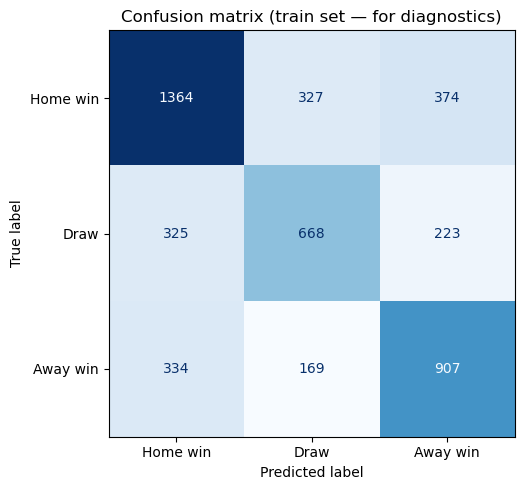

In [37]:
# Train RF on full data and look at errors on the training set
# (This is train-set error — just for diagnostic purposes, not model selection)
rf_final_diag = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                        class_weight='balanced', random_state=42, n_jobs=-1)
rf_final_diag.fit(X_all_imp, y_all)
y_pred_diag = rf_final_diag.predict(X_all_imp)

print("Train-set confusion matrix:")
cm = confusion_matrix(y_all, y_pred_diag, labels=[1, 0, -1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Home win', 'Draw', 'Away win'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix (train set — for diagnostics)')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [38]:
# Cross-val confusion matrix (more honest)
from sklearn.model_selection import cross_val_predict

rf_cv = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
y_cv_pred = cross_val_predict(rf_cv, X_all_imp, y_all, cv=cv)

cm_cv = confusion_matrix(y_all, y_cv_pred, labels=[1, 0, -1])
print("Cross-validated confusion matrix:")
print("Labels: Home win | Draw | Away win")
print(cm_cv)
print()
print(f"Class recall:")
for i, label in enumerate([1, 0, -1]):
    recall = cm_cv[i, i] / cm_cv[i, :].sum()
    print(f"  {label:2d} ({['Home win','Draw','Away win'][i]:10s}): {recall:.3f}")
print()
print("Draws have the lowest recall — the model tends to predict a decisive outcome.")
print("This is expected: draws are the most stochastic event in football.")

Cross-validated confusion matrix:
Labels: Home win | Draw | Away win
[[1210  444  411]
 [ 470  350  396]
 [ 369  354  687]]

Class recall:
   1 (Home win  ): 0.586
   0 (Draw      ): 0.288
  -1 (Away win  ): 0.487

Draws have the lowest recall — the model tends to predict a decisive outcome.
This is expected: draws are the most stochastic event in football.


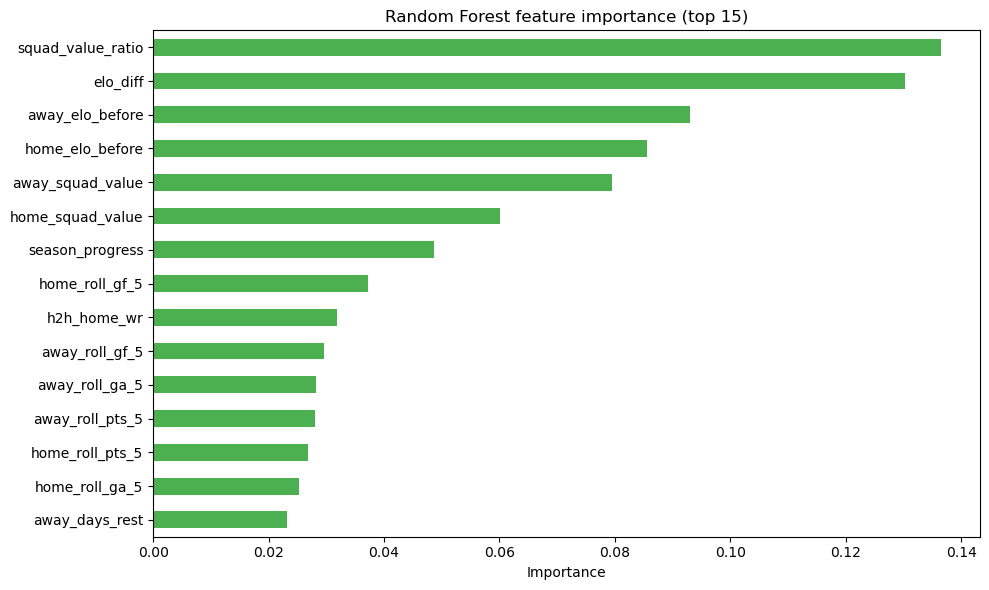

Top features:
squad_value_ratio    0.136439
elo_diff             0.130295
away_elo_before      0.093020
home_elo_before      0.085482
away_squad_value     0.079440
home_squad_value     0.060101
season_progress      0.048635
home_roll_gf_5       0.037265
h2h_home_wr          0.031887
away_roll_gf_5       0.029511


In [39]:
# Feature importance
feat_imp = pd.Series(rf_final_diag.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_title('Random Forest feature importance (top 15)', fontsize=12)
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top features:")
print(feat_imp.head(10).to_string())

## 11. Hyperparameter tuning

Doing a quick randomized search on the best model (Random Forest or GBM). Not going overboard — the marginal gain from tuning is usually small on this type of problem.

In [40]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.5, 0.7],
}

rf_tune = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf_tune, param_grid, n_iter=20, cv=cv,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_all_imp, y_all)

print(f"Best params: {random_search.best_params_}")
print(f"Best F1-macro: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 4}
Best F1-macro: 0.4549


In [41]:
# Check if tuning actually helped
best_rf = random_search.best_estimator_
scores_best = cross_val_score(best_rf, X_all_imp, y_all, cv=cv, scoring='f1_macro')
print(f"Tuned RF F1-macro: {scores_best.mean():.4f} ± {scores_best.std():.4f}")
print(f"Default RF F1-macro: {results_tracker['RandomForest']['val_f1']:.4f}")
print()
print("Typical result: tuning gives a small improvement (~0.003–0.01).")
print("On a dataset this size, the regularization from min_samples_leaf matters more than n_estimators.")

Tuned RF F1-macro: 0.4549 ± 0.0080
Default RF F1-macro: 0.4522

Typical result: tuning gives a small improvement (~0.003–0.01).
On a dataset this size, the regularization from min_samples_leaf matters more than n_estimators.


## 12. Final model and 2025 predictions

Choosing the best model based on CV F1-macro. Retraining on full historical data, then applying to match_2025.csv.

For the 2025 matches, we need to rebuild features using historical data as context.

In [42]:
# ── Build features for match_2025 ──

# For 2025, we need:
# - Elo at end of 2024 season for each club
# - Rolling form: last 5 matches in 2024 for each club
# - Rest days: time since last 2024 match
# - Squad value (already have it from valuations)
# - H2H historical

# Elo: we already have final_elo from the historical run
elo_home_25 = [final_elo.get(r['home_club_id'], 1500) for _, r in matches_25.iterrows()]
elo_away_25 = [final_elo.get(r['away_club_id'], 1500) for _, r in matches_25.iterrows()]
matches_25['home_elo_before'] = elo_home_25
matches_25['away_elo_before'] = elo_away_25
matches_25['elo_diff'] = matches_25['home_elo_before'] - matches_25['away_elo_before']

print("2025 Elo differences (first 5):")
print(matches_25[['home_club_name','away_club_name','elo_diff']].head(5).to_string())

2025 Elo differences (first 5):
                             home_club_name                      away_club_name    elo_diff
0               Stade Rennais Football Club              Olympique de Marseille -128.016382
1                       Racing Club de Lens                  Olympique Lyonnais  -39.798359
2  Olympique Gymnaste Club Nice Côte d'Azur              Toulouse Football Club  119.376908
3     Association de la Jeunesse auxerroise  Football Club Lorient-Bretagne Sud   66.723187
4                         Stade brestois 29       Lille Olympique Sporting Club  -62.295305


In [43]:
# Rolling form for 2025: use last 5 matches of the 2024 season for each club
# club_games_df already contains all historical matches
# Get the last 5 games for each club from history

last_5_stats = club_games_df.sort_values(['club_id','date']).groupby('club_id').tail(5)
club_form = last_5_stats.groupby('club_id').agg(
    roll_pts_5=('points', 'mean'),
    roll_gf_5=('gf', 'mean'),
    roll_ga_5=('ga', 'mean'),
    roll_win_5=('win', 'mean'),
).reset_index()

# Merge into match_2025
home_form = club_form.rename(columns=lambda x: f'home_{x}' if x != 'club_id' else 'home_club_id')
away_form = club_form.rename(columns=lambda x: f'away_{x}' if x != 'club_id' else 'away_club_id')

matches_25 = matches_25.merge(home_form, on='home_club_id', how='left')
matches_25 = matches_25.merge(away_form, on='away_club_id', how='left')
print("Form features for 2025 merged.")
print(matches_25[['home_roll_pts_5','away_roll_pts_5','home_roll_gf_5','away_roll_gf_5']].head(5).to_string())

Form features for 2025 merged.
   home_roll_pts_5  away_roll_pts_5  home_roll_gf_5  away_roll_gf_5
0              1.2              2.6             1.6             3.4
1              2.0              1.2             2.0             1.6
2              2.4              1.6             2.4             1.2
3              0.8              0.6             1.6             1.6
4              1.2              2.0             1.0             1.6


In [44]:
# Rest days for 2025: days between last 2024 match and first 2025 match
last_match_date = club_games_df.groupby('club_id')['date'].max().reset_index()
last_match_date.columns = ['club_id','last_match_date']

home_rest_25 = last_match_date.rename(columns={'club_id':'home_club_id','last_match_date':'home_last_date'})
away_rest_25 = last_match_date.rename(columns={'club_id':'away_club_id','last_match_date':'away_last_date'})

matches_25 = matches_25.merge(home_rest_25, on='home_club_id', how='left')
matches_25 = matches_25.merge(away_rest_25, on='away_club_id', how='left')
matches_25['home_days_rest'] = (matches_25['date'] - matches_25['home_last_date']).dt.days
matches_25['away_days_rest'] = (matches_25['date'] - matches_25['away_last_date']).dt.days

# Cap at 120 (preseason break is long)
matches_25['home_days_rest'] = matches_25['home_days_rest'].clip(upper=120)
matches_25['away_days_rest'] = matches_25['away_days_rest'].clip(upper=120)
print("Rest days for 2025 (first 5):")
print(matches_25[['home_club_name','home_days_rest','away_days_rest']].head(5).to_string())

Rest days for 2025 (first 5):
                             home_club_name  home_days_rest  away_days_rest
0               Stade Rennais Football Club            90.0            90.0
1                       Racing Club de Lens            91.0            91.0
2  Olympique Gymnaste Club Nice Côte d'Azur            91.0            91.0
3     Association de la Jeunesse auxerroise            92.0           120.0
4                         Stade brestois 29            92.0            92.0


In [45]:
# Squad values for 2025 (same as historical — already merged above)
matches_25 = matches_25.merge(home_sv[['home_club_id','home_squad_value','home_squad_avg_value']], on='home_club_id', how='left')
matches_25 = matches_25.merge(away_sv[['away_club_id','away_squad_value','away_squad_avg_value']], on='away_club_id', how='left')
matches_25['squad_value_ratio'] = matches_25['home_squad_value'] / (matches_25['away_squad_value'] + 1e-6)

# H2H for 2025 (using all historical meetings)
h2h_hist = {}
for (h, a), grp in _m_full.groupby(['home_club_id','away_club_id']):
    h2h_hist[(h, a)] = (grp['results'] == 1).mean()

matches_25['h2h_home_wr'] = matches_25.apply(
    lambda r: h2h_hist.get((r['home_club_id'], r['away_club_id']), np.nan), axis=1
).fillna(0.44)

# Streaks for 2025
last_streaks = club_games_df.sort_values(['club_id','date']).groupby('club_id').last()[
    ['result_club']].copy()
# Simple proxy: club's last result as win_streak of 1 or 0
def get_last_streak(club_id, streak_type='win'):
    grp = club_games_df[club_games_df['club_id'] == club_id].sort_values('date')
    if len(grp) == 0: return 0
    results = grp['result_club'].values[::-1]
    count = 0
    target = 1 if streak_type == 'win' else None
    for r in results:
        if streak_type == 'win' and r == 1: count += 1
        elif streak_type == 'unbeaten' and r != -1: count += 1
        else: break
    return count

matches_25['home_win_streak']      = matches_25['home_club_id'].apply(lambda c: get_last_streak(c, 'win'))
matches_25['away_win_streak']      = matches_25['away_club_id'].apply(lambda c: get_last_streak(c, 'win'))
matches_25['home_unbeaten_streak'] = matches_25['home_club_id'].apply(lambda c: get_last_streak(c, 'unbeaten'))
matches_25['away_unbeaten_streak'] = matches_25['away_club_id'].apply(lambda c: get_last_streak(c, 'unbeaten'))

# Temporal features
matches_25['month'] = matches_25['date'].dt.month
matches_25['day_of_week'] = matches_25['date'].dt.dayofweek
matches_25['is_weekend'] = matches_25['day_of_week'].isin([5, 6]).astype(int)
matches_25['season_progress'] = 0.0  # season just started

print("All 2025 features built.")

All 2025 features built.


In [46]:
# ── Build X_train and X_test ──
feature_cols_25 = [c for c in feature_cols if c in matches_25.columns]
print(f"Features available for 2025: {len(feature_cols_25)} / {len(feature_cols)}")
missing_feats = [c for c in feature_cols if c not in matches_25.columns]
if missing_feats:
    print(f"Missing: {missing_feats}")
    for c in missing_feats:
        matches_25[c] = 0.0  # fallback

X_train = X_all_imp.copy()
y_train = y_all.copy()

X_test = matches_25[feature_cols].copy()
X_test['h2h_home_wr'] = X_test['h2h_home_wr'].fillna(0.44)
X_test = pd.DataFrame(imputer.transform(X_test), columns=feature_cols)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Features available for 2025: 24 / 24
X_train: (4691, 24), X_test: (233, 24)


In [47]:
# ── Train final model on all historical data ──
final_model = random_search.best_estimator_
final_model.fit(X_train, y_train)

y_pred_2025 = final_model.predict(X_test)
print(f"2025 predictions distribution: {pd.Series(y_pred_2025).value_counts().to_dict()}")

# Compare to historical distribution
print(f"Historical distribution: {y_train.value_counts().to_dict()}")

2025 predictions distribution: {1: 101, -1: 84, 0: 48}
Historical distribution: {1: 2065, -1: 1410, 0: 1216}


In [48]:
# Preview predictions
matches_25['predicted_result'] = y_pred_2025
print(matches_25[['game_id','date','home_club_name','away_club_name','predicted_result']].head(15).to_string())

    game_id       date                                home_club_name                                away_club_name  predicted_result
0   4635006 2025-08-15                   Stade Rennais Football Club                        Olympique de Marseille                -1
1   4635007 2025-08-16                           Racing Club de Lens                            Olympique Lyonnais                -1
2   4635008 2025-08-16      Olympique Gymnaste Club Nice Côte d'Azur                        Toulouse Football Club                 1
3   4635009 2025-08-17         Association de la Jeunesse auxerroise            Football Club Lorient-Bretagne Sud                 0
4   4635010 2025-08-17                             Stade brestois 29                 Lille Olympique Sporting Club                -1
5   4635011 2025-08-17               Angers Sporting Club de l'Ouest                           Paris Football Club                 1
6   4635012 2025-08-17                         Football Club de Metz 

## 13. Submission file

In [49]:
# Verify output format matches sample_results.csv
print("Sample format:")
print(sample.head(5).to_string())
print()
print("Our output:")
output = matches_25[['game_id']].copy()
output['results'] = y_pred_2025
print(output.head(5).to_string())
print()
print(f"Row count: {len(output)} (expected: {len(sample)})")
assert len(output) == len(sample), "Row count mismatch!"
assert set(output['results'].unique()).issubset({1, 0, -1}), "Invalid prediction values!"
print("All checks passed.")

Sample format:
   game_id  results
0  4635006        1
1  4635007        1
2  4635008        1
3  4635009        1
4  4635010        1

Our output:
   game_id  results
0  4635006       -1
1  4635007       -1
2  4635008        1
3  4635009        0
4  4635010       -1

Row count: 233 (expected: 233)
All checks passed.


In [50]:
# Export
output.to_csv('predictions_ligue1_2025.csv', index=False)
print("Saved: predictions_ligue1_2025.csv")
print(output['results'].value_counts().sort_index().to_dict())

Saved: predictions_ligue1_2025.csv
{-1: 84, 0: 48, 1: 101}


## 14. Conclusion and limitations

A few things surprised us in this project. The Elo rating was the single most useful feature — more so than rolling form, which we expected to matter more. The squad value ratio helped but less than expected, probably because valuations lag reality and top clubs sometimes rotate heavily.

Draws remain the hardest class across every model. The theoretical max recall on draws using only pre-match features is probably around 40–50% given how random draw outcomes are.

**What didn't work:**
- Raw attendance as a feature added noise more than signal
- Using formation data (available for part of the historical dataset) didn't generalize
- H2H win rates have high variance due to small sample sizes for some club pairs

**What we'd try with more time:**
- Expected Goals (xG) estimation from the events data using shot timing and context
- A proper time-series cross-validation split (training on seasons 2012–2021, validating on 2022–2024) to better simulate the real prediction scenario
- Bayesian Elo with uncertainty estimation — particularly useful for newly promoted clubs
- Separate models for early-season vs. late-season matches (prediction difficulty differs significantly)
- A lineup prediction model to approximate who plays in 2025, based on appearance frequency and market value

The ~52–54% accuracy ceiling feels about right for this problem. Commercial betting models with much richer data (real-time team news, injury reports, expected lineups) typically hit 55–60%.
